# __Brief 04__ - **SBA Loans** : Est-ce que ce prêt doit être accordé ou rejetté ?

# Explication des colonnes

### Identification et localisation de l'entreprise

- **LoanNr_ChkDgt** : Numéro unique du prêt   <span style="color:red;">Useless</span>
- **Name** : Nom de l'entreprise bénéficiaire du prêt. <span style="color:red;">Useless</span>
- **City** : Ville où est située l'entreprise.  <span style="color:grey;">Redondant</span>
- **State** : État    <span style="color:green;">OK</span>
- **Zip** : Code postal   <span style="color:grey;">Redondant</span>

# Informations sur les prêts aux entreprises

## Informations sur la banque prêteuse

- **Bank** : Nom de la banque ayant accordé le prêt.  <span style="color:red;">Trop de valeurs uniques</span>
- **BankState** : État où est située la banque prêteuse.  <span style="color:green;">OK</span>

## Informations sur l'entreprise

- **NAICS** : Code de classification de l'industrie.   <span style="color:green;">OK</span>  -200.000 valeurs si not null notNaN
- **NoEmp** : Nombre d'employés de l'entreprise au moment de la demande de prêt.  <span style="color:green;">OK</span>
- **NewExist** : Indique si l'entreprise est nouvelle (**1**) ou existante (**2**). <span style="color:green;">OK</span> 

## Détails du prêt

- **ApprovalDate** : Date à laquelle le prêt a été approuvé.  <span style="color:red;">target leaking</span>
- **ApprovalFY** : Année fiscale d'approbation du prêt <span style="color:green;">OK</span>
- **Term** : Durée du prêt en mois.  <span style="color:green;">OK</span>
- **CreateJob** : Nombre d'emplois que l'entreprise prévoit de créer grâce au prêt.  <span style="color:green;">OK</span>
- **RetainedJob** : Nombre d'emplois que l'entreprise prévoit de conserver grâce au prêt.  <span style="color:green;">OK</span>
- **FranchiseCode** : Code indiquant si l'entreprise est une franchise (**00000** signifie que ce n'est pas une franchise).  <span style="color:green;">OK</span>
- **UrbanRural** : Indique si l'entreprise est située dans une zone **urbaine** (**1**), **rurale** (**2**), ou **non spécifiée** (**0**).  <span style="color:green;">OK</span>

## Conditions du prêt

- **RevLineCr** : Indique si le prêt est une ligne de crédit renouvelable <span style="color:green;">OK</span> 
- **LowDoc** : Indique si le prêt fait partie du programme *Low Documentation* <span style="color:green;">OK</span>

## Informations financières et remboursement

- **ChgOffDate** : Date à laquelle le prêt a été radié en cas de non-remboursement.  <span style="color:red;">target Leaking</span>
- **DisbursementDate** : Date à laquelle les fonds ont été décaissés.  <span style="color:red;">target leaking</span>
- **DisbursementGross** : Montant total du prêt accordé.  <span style="color:green;">OK</span>
- **BalanceGross** : Montant restant dû sur le prêt.  <span style="color:red;">target Leaking</span>
- **MIS_Status** : Statut du prêt :  <span style="color:yellow;">TARGET</span>
  - **PIF (Paid In Full)** : Le prêt a été remboursé intégralement.  
  - **CHGOFF (Charged Off)** : Le prêt a été radié (perte pour la banque).  
- **ChgOffPrinGr** : Montant du principal du prêt qui a été radié (perdu par la banque).  <span style="color:red;">Target leaking</span>
- **GrAppv** : Montant total approuvé par la banque.  <span style="color:grey;">redondant avec DisbursementGross?</span>
- **SBA_Appv** : Montant garanti par la *SBA* (une partie du prêt est garantie par l'agence).  <span style="color:red;">Target leaking</span>


In [25]:
# Importation des librairies

import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency                   #CHI2
from scipy.stats import f_oneway                           #ANOVA
from scipy.stats import pointbiserialr

from sklearn.experimental import enable_iterative_imputer  # Nécessaire pour activer l'IterativeImputer
from sklearn.impute import IterativeImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder



In [26]:
df = pd.read_csv("data/SBAnational.csv")
df.head(3)
# label_encoder = LabelEncoder()
# df['State'] = label_encoder.fit_transform(df['State'])
# df['BankState'] = label_encoder.fit_transform(df['BankState'])

/tmp/ipykernel_115843/292138615.py:1: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/SBAnational.csv")


,LoanNr_ChkDgt,Name,City,State,Zip,Bank,BankState,NAICS,ApprovalDate,ApprovalFY,...,RevLineCr,LowDoc,ChgOffDate,DisbursementDate,DisbursementGross,BalanceGross,MIS_Status,ChgOffPrinGr,GrAppv,SBA_Appv
0,1000014003,ABC HOBBYCRAFT,EVANSVILLE,IN,47711,FIFTH THIRD BANK,OH,451120,28-Feb-97,1997,...,N,Y,NaN,28-Feb-99,"$60,000.00",$0.00,P I F,$0.00,"$60,000.00","$48,000.00"
1,1000024006,LANDMARK BAR & GRILLE (THE),NEW PARIS,IN,46526,1ST SOURCE BANK,IN,722410,28-Feb-97,1997,...,N,Y,NaN,31-May-97,"$40,000.00",$0.00,P I F,$0.00,"$40,000.00","$32,000.00"
2,1000034009,"WHITLOCK DDS, TODD M.",BLOOMINGTON,IN,47401,GRANT COUNTY STATE BANK,IN,621210,28-Feb-97,1997,...,N,N,NaN,31-Dec-97,"$287,000.00",$0.00,P I F,$0.00,"$287,000.00","$215,250.00"


## 1. Visualisation du Dataset brut

-> Dataset assez complet except ChOffDate


In [27]:
df.isnull().sum()

LoanNr_ChkDgt             0
Name                     14
City                     30
State                    14
Zip                       0
Bank                   1559
BankState              1566
NAICS                     0
ApprovalDate              0
ApprovalFY                0
Term                      0
NoEmp                     0
NewExist                136
CreateJob                 0
RetainedJob               0
FranchiseCode             0
UrbanRural                0
RevLineCr              4528
LowDoc                 2582
ChgOffDate           736465
DisbursementDate       2368
DisbursementGross         0
BalanceGross              0
MIS_Status             1997
ChgOffPrinGr              0
GrAppv                    0
SBA_Appv                  0
dtype: int64

In [28]:
for column in df.columns:
    missing_value = df[column].isnull().sum()
    # print(missing_value)
    if missing_value > 0 :
        print(f"{column.ljust(20, ' ')}: {str(missing_value).rjust(1, ' ')} valeurs manquantes")

Name                : 14 valeurs manquantes
City                : 30 valeurs manquantes
State               : 14 valeurs manquantes
Bank                : 1559 valeurs manquantes
BankState           : 1566 valeurs manquantes
NewExist            : 136 valeurs manquantes
RevLineCr           : 4528 valeurs manquantes
LowDoc              : 2582 valeurs manquantes
ChgOffDate          : 736465 valeurs manquantes
DisbursementDate    : 2368 valeurs manquantes
MIS_Status          : 1997 valeurs manquantes


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 899164 entries, 0 to 899163
Data columns (total 27 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   LoanNr_ChkDgt      899164 non-null  int64  
 1   Name               899150 non-null  object 
 2   City               899134 non-null  object 
 3   State              899150 non-null  object 
 4   Zip                899164 non-null  int64  
 5   Bank               897605 non-null  object 
 6   BankState          897598 non-null  object 
 7   NAICS              899164 non-null  int64  
 8   ApprovalDate       899164 non-null  object 
 9   ApprovalFY         899164 non-null  object 
 10  Term               899164 non-null  int64  
 11  NoEmp              899164 non-null  int64  
 12  NewExist           899028 non-null  float64
 13  CreateJob          899164 non-null  int64  
 14  RetainedJob        899164 non-null  int64  
 15  FranchiseCode      899164 non-null  int64  
 16  Ur

In [30]:
var_continues = ["GrAppv", "SBA_Appv", "Term", "DisbursementGross", "GrAppv", "SBA_Appv"]
var_discretes = ["NoEmp", "CreateJob", "RetainedJob", "ApprovalFY"]
var_nominales = ["State", "BankState", "NAICS", "NewExist", "RevLineCr", "LowDoc"]
var_ordinales = ["MIS_Status", "FranchiseCode" ]

# Affichage des classifications
print("Variables catégorielles nominales :", list(var_nominales))
print("Variables catégorielles ordinales :", var_ordinales)
print("Variables numériques discrètes :", list(var_discretes))
print("Variables numériques continues :", list(var_continues))

Variables catégorielles nominales : ['State', 'BankState', 'NAICS', 'NewExist', 'RevLineCr', 'LowDoc']
Variables catégorielles ordinales : ['MIS_Status', 'FranchiseCode']
Variables numériques discrètes : ['NoEmp', 'CreateJob', 'RetainedJob', 'ApprovalFY']
Variables numériques continues : ['GrAppv', 'SBA_Appv', 'Term', 'DisbursementGross', 'GrAppv', 'SBA_Appv']


<Axes: >

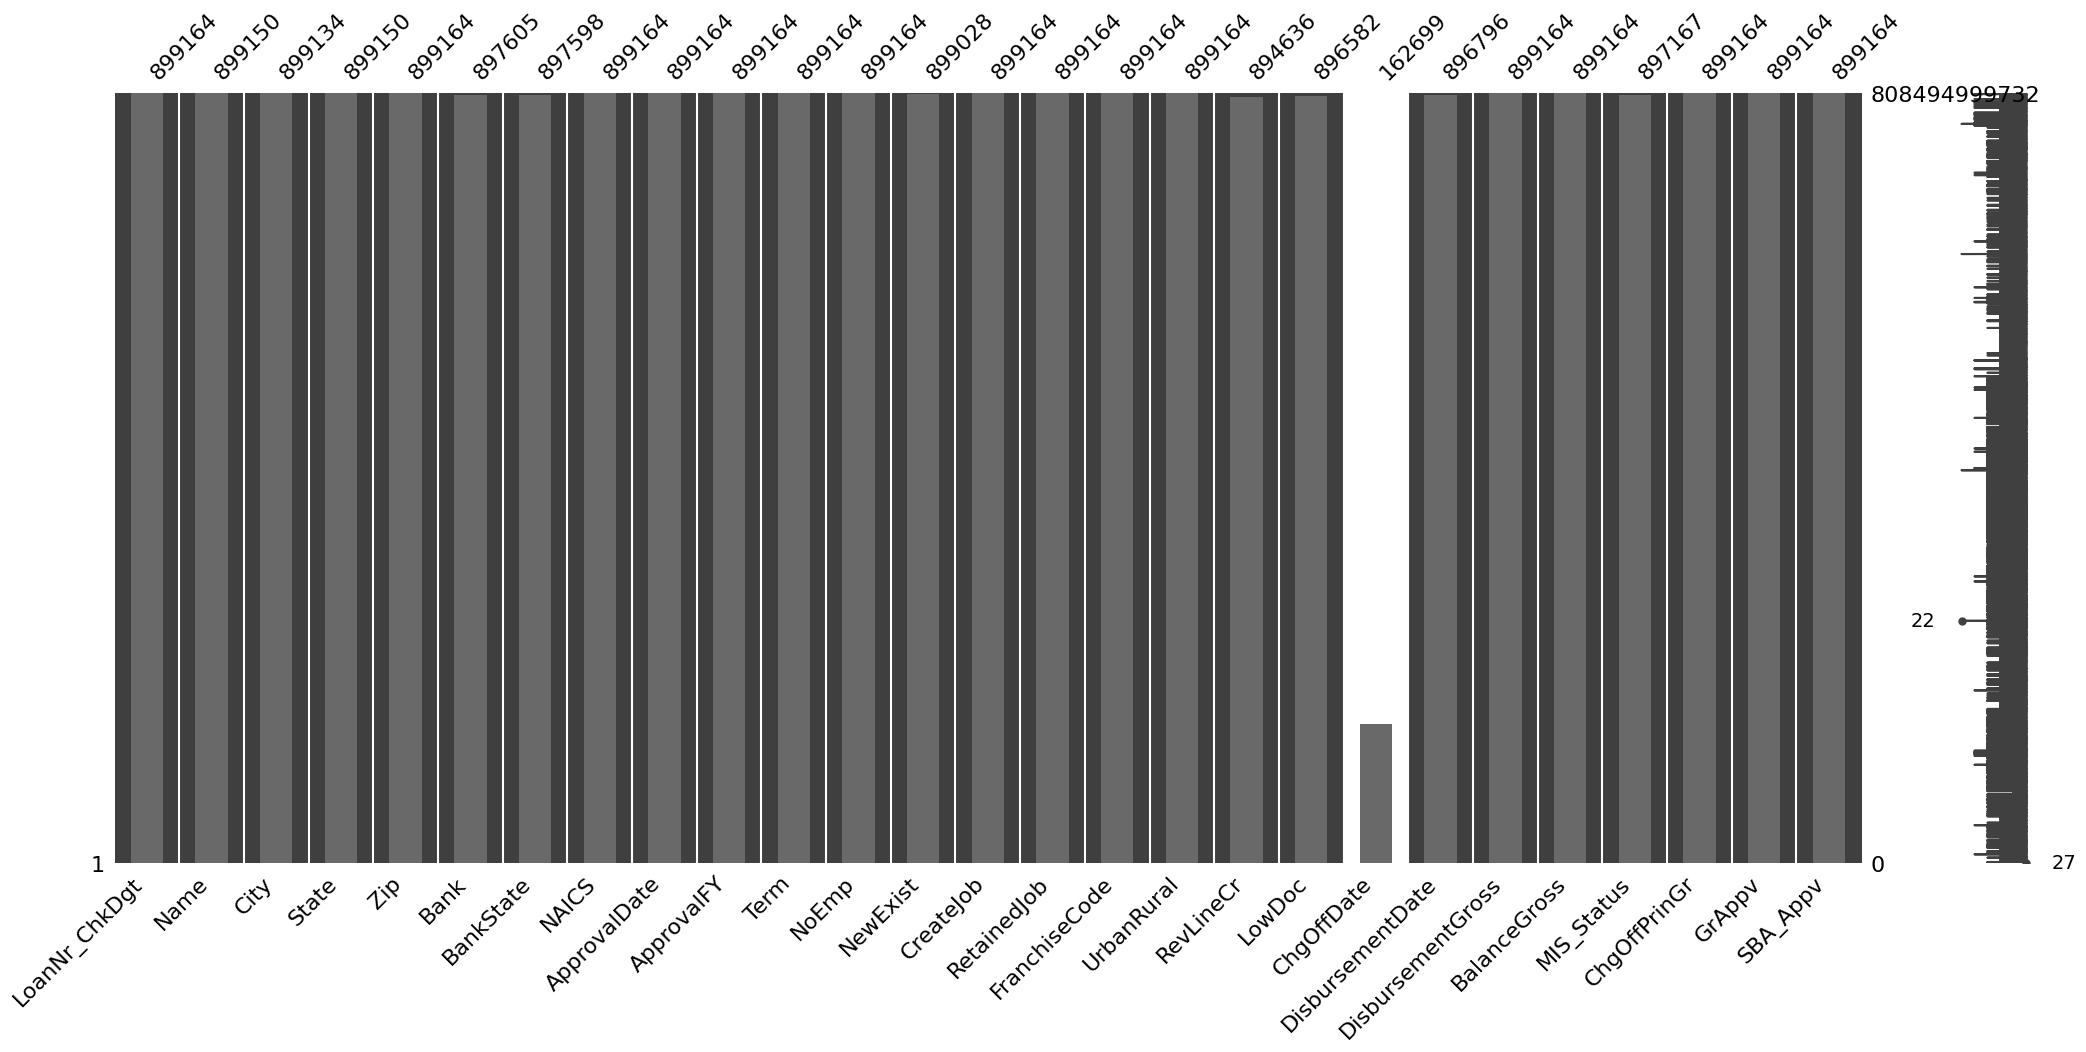

In [31]:
msno.matrix(df)
msno.bar(df)

# 2. Numérisation des variables

In [32]:
df['NAICS'] = df['NAICS'].astype(str).str[:2]  # Remplace par les 2 premiers chiffres du code -> Catégorie

df["FranchiseCode"] = df["FranchiseCode"].where(df["FranchiseCode"] == 0, 1) # tous les chiffres >1 sont différentes franchises donc == 1

df["RevLineCr"] = df["RevLineCr"].map(lambda x: 0 if x in ["N", "0"] else (1 if x in ["Y", "1"] else np.nan))   # 0,1 ou Nan (pour une future IterativeImputer)

df["LowDoc"] = df["LowDoc"].map(lambda x: 0 if x == "N" else (1 if x == "Y" else np.nan))

df["DisbursementDate"] = pd.to_datetime(df["DisbursementDate"], format="%d-%b-%y")

df["MIS_Status"] = df["MIS_Status"].map(lambda x: 1 if x == "P I F" else (0 if x== "CHGOFF" else np.nan) )  # Vérifier si Imputation possible de NaN

df['ChgOffPrinGr'] = df['ChgOffPrinGr'].replace('[$,]', '', regex=True).astype(float)

df['DisbursementGross'] = df['DisbursementGross'].replace('[$,]', '', regex=True).astype(float)

df['GrAppv'] = df['GrAppv'].replace('[$,]', '', regex=True).astype(float)

df['SBA_Appv'] = df['SBA_Appv'].replace('[$,]', '', regex=True).astype(float)
# df['DisbursementDate'] = df['DisbursementDate'].astype(str).str[:4]
# df["DisbursementDate"] = df["DisbursementDate"].astype(int)
df['ApprovalFY'] = pd.to_numeric(df['ApprovalFY'].astype(str).str[:4], errors='coerce').astype('Int64')



# 3. IMPUTATION

## 3.1. Imputation de la target : MIS_STatus

In [33]:
df["MIS_Status"].unique()

array([ 1.,  0., nan])

In [34]:
dftest = df[["MIS_Status","ChgOffPrinGr"]].dropna()
# Calcul de la corrélation bisériale pointée entre MIS_Status et ChgOffPrinGr  (utilisée comme un Pearson entre une continue et une binaire)
corr, p_value = pointbiserialr(dftest['MIS_Status'], dftest['ChgOffPrinGr'])

print(f"Corrélation bisériale : {corr}")
print(f"p-value : {p_value}")

Corrélation bisériale : -0.444811932096145
p-value : 0.0


Il existe une corrélation significative entre MIS_Status et ChgOffPrinGr,on peut donc
procéder à une imputation 

In [35]:
df['MIS_Status'] = df.apply(lambda x: 1 if x['ChgOffPrinGr'] == 0 else 0, axis=1)

In [36]:
df[["MIS_Status","ChgOffPrinGr"]]
# Test ANOVA
f_stat, p_value = f_oneway(dftest["MIS_Status"], dftest["ChgOffPrinGr"])

# Affichage des résultats
print(f"Statistique F : {f_stat}")
print(f"p-value : {p_value}")


Statistique F : 38602.04793651453
p-value : 0.0


## 3.2. Imputation de la colonne State
Utilisation des lignes ZIP et City

In [37]:
import numpy as np

# Fonction pour récupérer la valeur de 'State' selon 'Zip' ou 'City'
def impute_state(row):
    if pd.isnull(row['State']):  # Vérifier si 'State' est manquant
        # Chercher si d'autres lignes avec le même 'Zip' ont un 'State' valide
        state_from_zip = df.loc[(df['Zip'] == row['Zip']) & (df['State'].notna()), 'State']
        if not state_from_zip.empty:
            return state_from_zip.mode()[0]  # Prendre la valeur la plus fréquente si plusieurs existent
        
        # Chercher si d'autres lignes avec la même 'City' ont un 'State' valide
        state_from_city = df.loc[(df['City'] == row['City']) & (df['State'].notna()), 'State']
        if not state_from_city.empty:
            return state_from_city.mode()[0]  # Prendre la valeur la plus fréquente si plusieurs existent
    
    return row['State']  # Si aucune correspondance, on garde la valeur existante (NaN si non trouvé)

# Appliquer l'imputation
df['State'] = df.apply(impute_state, axis=1)

# Vérification après l'imputation
print(df['State'].isnull().sum()) 

1


# 4. Feature Engineering

## - 4.1. **Recession year**

Les récessions sont marquées par une période d'au moins six mois de contraction économique. Pour une régression, cette variable peut être utilisée comme cible ou comme variable explicative.

In [38]:
recession_data = {
    "Année": list(range(1961, 2021)),
    "Récession": [
        0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 
        1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 
        1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1
    ]
}

recession_data["Récession"][:5]



[0, 0, 0, 0, 0]

In [39]:
# Créer un dictionnaire avec les années et les valeurs de récession
recession_dict = dict(zip(recession_data["Année"], recession_data["Récession"]))

# Ajouter une colonne 'Recession' dans df, avec 1 si l'année est une récession, 0 sinon
df['Recession'] = df['ApprovalFY'].map(recession_dict).fillna(0).astype(int)

df[['Recession', 'ApprovalFY']]

,Recession,ApprovalFY
0,0,1997
1,0,1997
2,0,1997
3,0,1997
4,0,1997
...,...,...
899159,0,1997
899160,0,1997
899161,0,1997
899162,0,1997


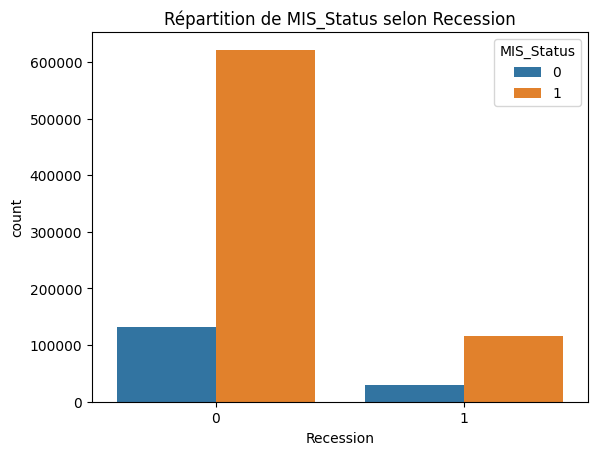

In [40]:
# Vérifier la répartition de MIS_Status en fonction de Recession
sns.countplot(x="Recession", hue="MIS_Status", data=df)
plt.title("Répartition de MIS_Status selon Recession")
plt.show()


In [41]:

# Calcul du ratio de MIS_Status selon Recession
ratio = df.groupby("Recession")["MIS_Status"].value_counts(normalize=True).unstack() * 100

# Afficher les résultats
print(ratio)


MIS_Status          0          1
Recession                       
0           17.524373  82.475627
1           20.578462  79.421538


## **Bank Class** : small / medium / large
Donne un indice sur la solvabilité de la banque

# 5. FEATURE SELECTION : Création d'un nouveau DataFrame 

In [42]:
columns_to_keep = ['State','BankState','NAICS', 'NoEmp', 'NewExist', 'RetainedJob', 'CreateJob', 'UrbanRural', 'RevLineCr', 'ApprovalFY', 'Recession', 'Term', 'FranchiseCode', 'DisbursementGross', 'GrAppv', 'SBA_Appv',  'LowDoc', 'MIS_Status']
df2 = df[columns_to_keep]

## Ne pas encoder

In [43]:
# encoder = OneHotEncoder(sparse_output=False, drop='first')
# # Encodage de 'State'
# state_encoded = encoder.fit_transform(df2[['State']])
# state_df = pd.DataFrame(state_encoded, columns=encoder.get_feature_names_out(['State']))

# # Encodage de 'BankState'
# bankstate_encoded = encoder.fit_transform(df2[['BankState']])
# bankstate_df = pd.DataFrame(bankstate_encoded, columns=encoder.get_feature_names_out(['BankState']))

# # Fusion avec le DataFrame original (en supprimant les colonnes encodées)
# df2 = pd.concat([df2.drop(['State', 'BankState'], axis=1), state_df, bankstate_df], axis=1)


In [44]:
# # Initialisation de l'IterativeImputer
# imputer = IterativeImputer(max_iter=10, random_state=42)

# # Appliquer l'imputation
# df_imputed = pd.DataFrame(imputer.fit_transform(df2), columns=df2.columns)

# # Afficher le DataFrame après imputation
# print(df_imputed)

# Tests statistiques
## CHi2

In [45]:
# Boucle de test Chi2 entre MIS_Status et les autres variables catégorielles
for var in var_nominales + var_ordinales:
    contingency_table = pd.crosstab(df['MIS_Status'], df[var])  # Créer un tableau de contingence
    chi2, p, _, _ = chi2_contingency(contingency_table)  # Test du Chi2
    print(f"Test Chi2 entre MIS_Status et {var} : p-value = {p}")

Test Chi2 entre MIS_Status et State : p-value = 0.0
Test Chi2 entre MIS_Status et BankState : p-value = 0.0
Test Chi2 entre MIS_Status et NAICS : p-value = 0.0
Test Chi2 entre MIS_Status et NewExist : p-value = 3.407841179691204e-104
Test Chi2 entre MIS_Status et RevLineCr : p-value = 0.0
Test Chi2 entre MIS_Status et LowDoc : p-value = 0.0
Test Chi2 entre MIS_Status et MIS_Status : p-value = 0.0
Test Chi2 entre MIS_Status et FranchiseCode : p-value = 0.0


In [46]:
# corr_matrix = df2.corr()
# print(corr_matrix)


In [47]:
# plt.figure(figsize=(12, 8))  # Ajuste la taille
# sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
# plt.title("Matrice de corrélation")
# plt.show()

# Df to CSV

In [48]:
df2.to_csv('data/cleaned_data.csv', index=False)  # index=False pour ne pas inclure l'index dans le fichier